# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from meteostat import Point, Stations, Daily
import folium

# Ort auf Karte markieren

Wir können mit Python und dem folium-Package Punkte auf einer Karte markieren.

Aufgabe: Zeichnen Sie Ihren genauen Wohnort ein!
1. Dazu müssen Sie die zuerst die Koordinaten finden. Suchen Sie dafür Ihre Adresse auf https://map.geo.admin.ch.
2. Klicken Sie auf den Marker und lesen Sie die Koordinaten im WGS84-Format (lat/lon) (World Geodetic System 1984)
3. Tragen Sie die lat und lon-Werte unten im Pythonskript ein.

In [ ]:
# Standort definieren (Beispiel: lat/lon vorher setzen)
# Ort: Horw
lat = 47.013912
lon = 8.305558

point = Point(lat, lon)

# Karte definieren
m = folium.Map(
    location=[lat, lon],
    zoom_start=12,
    tiles="Cartodb voyager" # versuche "OpenTopoMap"
)
folium.Marker([lat, lon], tooltip="Mein Zuhause", popup=f"Hier wohne ich!").add_to(m) # f"Meine Koordinaten sind:<br>lat: {lat:.2f}<br>lon: {lon:.2f}")
m

# Wetteranalyse

Für Ihre Koordinaten wollen wir uns nun die letztjährigen Wetterdaten anschauen. Können wir damit vielleicht eine Aussage über den Energieverbrauch machen?

## Wetterinformationen beziehen

Mit dem meteostat-Package können die Wetterinformationen für beliebige Koordinaten und vergangene Jahre ausgelesen werden. Die Daten können dann mit einem pandas Dataframe analysiert und bearbeitet werden.

In [ ]:
# nahe Wetterstationen suchen
stations = Stations()
stations = stations.nearby(lat, lon)
stations = stations.fetch(4)

# Zeitraum definieren
start = datetime(2025, 1, 1)
end = datetime(2025, 12, 31)

# Tagesdaten holen (Stationsdaten → Punkt)
data = Daily(point, start, end)
df = data.fetch()

df.head()

,temp,tmin,tmax,rhum,prcp,wspd,wpgt,pres,tsun,cldc
time,,,,,,,,,,
2025-01-01,-0.1,-2.7,4.1,86,0.0,4.0,11.1,1029.6,157,3
2025-01-02,1.9,-1.6,5.4,82,14.1,5.3,31.5,1019.4,9,7
2025-01-03,0.5,-1.4,1.7,87,7.6,4.6,22.2,1024.2,19,7
2025-01-04,-1.7,-3.9,0.2,83,1.3,3.5,11.1,1022.3,63,7
2025-01-05,3.4,-0.4,6.9,93,9.1,3.5,11.1,1008.9,1,8


## Plot

Wir plotten den Temperaturverlauf für die gewählten Koordinaten.

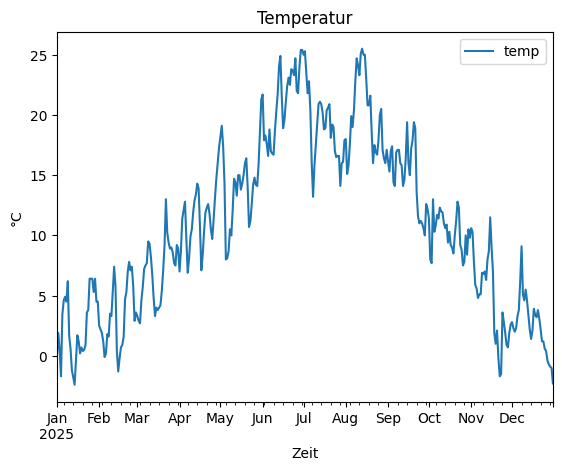

In [ ]:
df[["tavg"]].plot()
# plt.plot(df.index, df[["temp"]], marker="o")
plt.title("Temperatur")
plt.xlabel("Zeit")
plt.ylabel("°C")
plt.show()

Wir können uns auch andere Informationen wie zB. die Sonnenscheindauer anzeigen lassen.

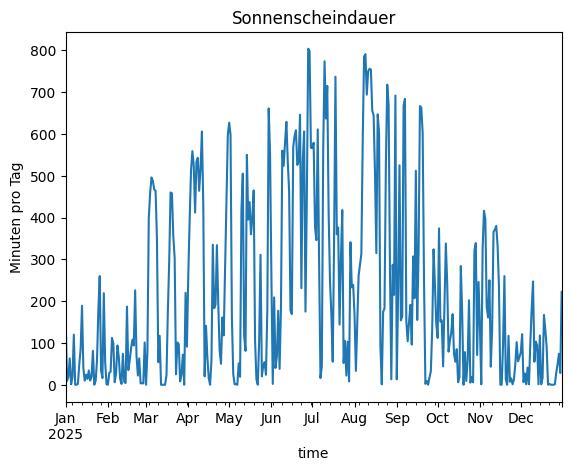

In [ ]:
df['tsun'].plot()
plt.title("Sonnenscheindauer")
plt.xlabel("Zeit")
plt.ylabel("Minuten pro Tag")
plt.show()

## Analyse
### Heizgradtage

Wir versuchen nun aus dem Temperaturverlauf Erkenntnisse für energetische Betrachtungen zu ziehen. Dafür schauen wir uns das Konzept der Heizgradstunden an.

Die Idee der Heizgradtage ist ein relativer einfacher Weg, um den Heizbedarf an einem Ort abzuschätzen.

#### Plot

Wir plotten zunächst die Temperatur erneut. Zusätzlich zeichnen wir eine Linie für die Tagesaussentemperatur (hier: 12°C), ab welcher nicht geheizt werden muss. Das heisst, falls die Tagesaussentemperatur unter 12°C fällt, dann wird geheizt.

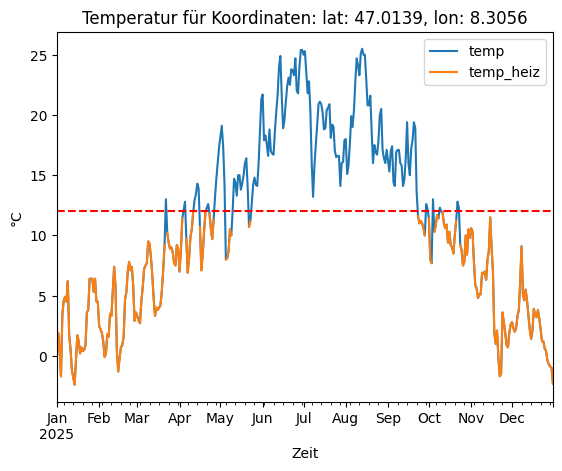

In [ ]:
thresh = 12 # Threshold: 12°C (Wenn die Temperatur unter 12°C fällt, wird geheizt)

heiztage = df['tavg'] < thresh
df["tavg_heiz"] = df["tavg"].where(heiztage, None)

df[["tavg", "tavg_heiz"]].plot()
plt.axhline(thresh, linestyle="--", color="red") # Threshold einzeichnen
plt.title(f"Temperatur für Koordinaten: lat: {lat:.4f}, lon: {lon:.4f}")
plt.xlabel("Zeit")
plt.ylabel("°C")
plt.show()

#### Berechnung von Heizgradtagen

Wir nehmen an, dass sich der Heizbedarf proportional zur Differenz von Aussen- und Innentemperatur verändert. Für die Innentemperatur nehmen wir eine angenehme Temperatur von 20°C an.


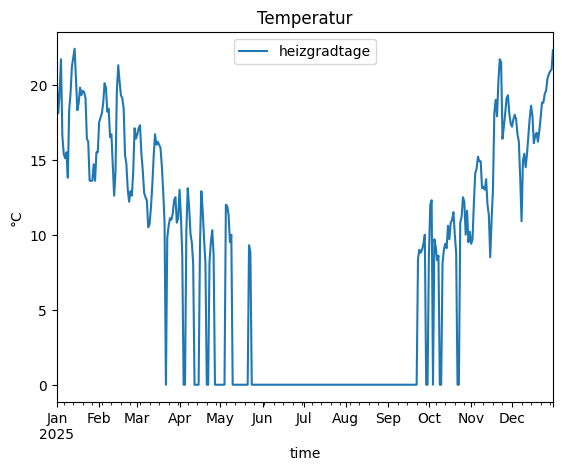

In [ ]:
raum_temp = 20

df["heizgradtage"] = raum_temp - df["tavg_heiz"]
df["heizgradtage"] = df["heizgradtage"].fillna(0)

df[["heizgradtage"]].plot()
plt.title("Heizgradtage")
plt.xlabel("Zeit")
plt.ylabel("°C")
plt.show()

#### Jährlicher Bedarf

Für den jährlichen Bedarf abschätzen zu können, summieren wir die Heizgradtage. Wichtig: Die Heizgradtage ist nicht der Heizbedarf. Er ist lediglich ein Konzept, den Bedarf vergleichen zu können. Um den absoluten Bedarf zu erhalten, müssen die Heizgradtage noch mit entsprechenden Faktoren (zB. Baujahr, Grösse und Kategorie des Gebäude) multipliziert werden.

In [ ]:
heizgradtage_jahr = df["heizgradtage"].sum()